In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


### Load Data

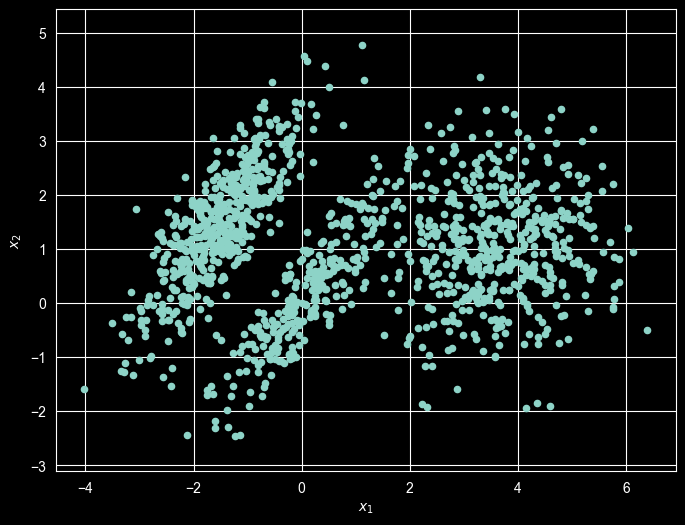

In [87]:
np.random.seed(42)
means = [[-1.5, 1.5], [3.5, 1.0], [0.0, 0.0]]
covariances = [[[0.6, 0.7], [0.7, 1.2]], [[1.2, 0], [0, 1]], [[0.7, 0.8], [0.8, 1.2]]]
X1 = np.random.multivariate_normal(means[0], covariances[0], 500)
X2 = np.random.multivariate_normal(means[1], covariances[1], 500)
X3 = np.random.multivariate_normal(means[2], covariances[2], 250)
X = np.vstack([X1, X2, X3])
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=20)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")
plt.show()

## Model

In [88]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [89]:
gm.weights_

array([0.40276649, 0.39216175, 0.20507176])

In [90]:
gm.means_

array([[-1.50630957,  1.50245329],
       [ 3.61465873,  1.06171324],
       [ 0.10029586,  0.14673323]])

In [91]:
gm.covariances_

array([[[0.57330426, 0.66595693],
        [0.66595693, 1.1669396 ]],

       [[1.00316761, 0.07204939],
        [0.07204939, 1.06018064]],

       [[0.68930993, 0.80408365],
        [0.80408365, 1.18519221]]])

In [92]:
gm.converged_

True

In [93]:
gm.n_iter_

11

In [94]:
gm.predict(X)

array([0, 0, 0, ..., 2, 2, 2], shape=(1250,))

In [95]:
gm.predict_proba(X).round(3)

array([[1.   , 0.   , 0.   ],
       [1.   , 0.   , 0.   ],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 0.03 , 0.97 ],
       [0.   , 0.003, 0.997],
       [0.   , 0.   , 1.   ]], shape=(1250, 3))

In [96]:
X_new, y_new = gm.sample(1)
X_new, y_new

(array([[-0.7919764 , -0.26830004]]), array([2]))

In [97]:
gm.score_samples(X).round(2)

array([-2.14, -3.35, -2.06, ..., -3.52, -2.6 , -3.02], shape=(1250,))